In [19]:
%pip install --disable-pip-version-check --quiet -U langchain==0.2.16
%pip install --disable-pip-version-check --quiet -U langchain_openai==0.1.23
%pip install --disable-pip-version-check --quiet -U langgraph==0.2.19
%pip install --disable-pip-version-check --quiet -U langchainhub==0.1.21
%pip install --disable-pip-version-check --quiet -U tavily-python==0.4.0
%pip install --disable-pip-version-check --quiet -U langchain-community==0.2.16
%pip install --disable-pip-version-check --quiet -U python-dotenv==1.0.1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [20]:
# Load in the OpenAI key and Tavily key.
# In the project folder, create a file named 'config.env'
# ensure your .env file contains keys named OPENAI_API_KEY="your key" and TAVILY_API_KEY="your key"
from dotenv import load_dotenv
import os

load_dotenv('config.env')
assert os.getenv('OPENAI_API_KEY') is not None
assert os.getenv('TAVILY_API_KEY') is not None

In [39]:
import time
from typing import Literal
from IPython.display import display, Image

# LangGraph and LangChain imports
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage

# --- Utility functions ---
def show_to_patient(message: str):
    """Print a message to the console with a slight delay for readability."""
    print(message)
    time.sleep(1)

def get_patient_input(prompt_text: str) -> str:
    """Ask the patient for input and return their response."""
    return input(prompt_text)

# --- State definition ---
class HealthBotState(MessagesState):
    """Tracks the evolving state of the HealthBot workflow."""
    topic: str
    summary: str
    quiz: str
    quiz_ground_truth: str
    answer: str
    grade: str

# --- Model and tools setup ---
# Configure the OpenAI chat model (keys and base URL should be set via environment variables)
chat_model = ChatOpenAI(
    temperature=0,
    streaming=True,
    base_url="https://openai.vocareum.com/v1"  # adjust if your environment uses OPENAI_API_BASE
)

# Tavily search tool for retrieving medical information
search_tool = TavilySearchResults(max_results=5)

# Bind tools to the model so it can call Tavily during the workflow
chat_with_tools = chat_model.bind_tools([search_tool])

In [22]:
def collect_patient_topic(state: HealthBotState):
    """Ask the patient which health subject they want to learn about and initialize the dialogue."""

    # Prompt the patient for their chosen topic
    selected_topic = get_patient_input("Which health condition or topic would you like to learn about today? ")

    # Construct the initial system and human messages for the agent
    initial_context = [
        SystemMessage(
            content=(
                "You are HealthBot. Your responsibility is to research the patient's chosen health topic "
                "using the available tools, then produce a clear 3–4 paragraph summary in simple, "
                "patient‑friendly language. Only rely on the search results provided—do not add outside knowledge."
            )
        ),
        HumanMessage(content=selected_topic)
    ]

    # Update the state with the topic and initial messages
    return {"topic": selected_topic, "messages": initial_context}

In [23]:
def run_agent_node(state: HealthBotState):
    """Call the chat model with tools to process the current message list."""
    
    # Let the patient know the agent is working
    show_to_patient("Processing your request...")

    # Retrieve the conversation history from state
    current_msgs = state["messages"]

    # Invoke the model with the bound tools
    agent_reply = chat_with_tools.invoke(current_msgs)

    # Append the agent's response to the message list
    updated_msgs = current_msgs + [agent_reply]

    # Return the updated state
    return {"messages": updated_msgs}

In [24]:
def execute_search_tool(state: HealthBotState):
    """Run the Tavily search tool based on the agent's last tool call and update the state."""

    # Notify the patient that a search is being performed
    show_to_patient(f"Looking up information on {state['topic']}...")

    # Get the most recent message, which should contain a tool call
    latest_msg = state["messages"][-1]
    tool_call_info = latest_msg.tool_calls[0]

    # Execute the Tavily search with the provided arguments
    search_results = search_tool.invoke(tool_call_info["args"])

    # Display raw Tavily output for debugging/visibility
    print("---- Tavily Output ----", search_results)

    # Wrap the tool output in a ToolMessage so it can be added to the conversation
    search_msg = ToolMessage(
        content=str(search_results),
        tool_call_id=tool_call_info["id"]
    )

    # Return updated state with the new tool message appended
    return {"messages": state["messages"] + [search_msg]}


In [25]:
def generate_summary(state: HealthBotState):
    """Summarize the search results into a patient-friendly explanation."""

    # Notify the patient that summarization is in progress
    show_to_patient("Creating a summary of the information...")

    # Collect all tool messages from the state
    tool_msgs = [msg for msg in state["messages"] if isinstance(msg, ToolMessage)]
    combined_output = "\n\n".join([msg.content for msg in tool_msgs])

    # Handle case where no tool results are available
    if not combined_output:
        fallback_summary = "No reliable information was retrieved for the selected topic."
        return {"summary": fallback_summary, "messages": [AIMessage(content=fallback_summary)]}

    # Build the summarization prompt
    prompt_text = f"""
    The patient asked about "{state['topic']}". Using only the search results below,
    write a clear 3–4 paragraph explanation that is easy to understand.
    Do not add any outside knowledge.

    Search Results:
    {combined_output}
    """

    # Invoke the model to generate the summary
    response = chat_model.invoke([HumanMessage(content=prompt_text)])
    summary_text = response.content

    # Return updated state with summary and message
    return {"summary": summary_text, "messages": [AIMessage(content=summary_text)]}

In [26]:
def show_summary(state: HealthBotState):
    """Display the generated summary back to the patient."""

    # Present the summary header
    show_to_patient("Here is the summary of the information you requested:")

    # Present the actual summary text
    show_to_patient(state["summary"])

    # Return the summary so it remains in state
    return {"summary": state["summary"], "messages": [state["summary"]]}

In [27]:
def wait_for_quiz_ready(state: HealthBotState):
    """Pause until the patient confirms they are ready for the comprehension quiz."""

    # Ask the patient to press Enter when they are ready
    get_patient_input("Press Enter once you feel prepared to take the comprehension check.")

    # Return the topic so it remains in state
    return {"topic": state["topic"], "messages": [f"Patient is ready for quiz on {state['topic']}"]}

In [28]:
def create_quiz_question(state: HealthBotState):
    """Generate a single multiple-choice quiz question from the summary."""

    # Notify the patient that a quiz is being created
    show_to_patient("Preparing a comprehension quiz question...")

    # Build the prompt for the model
    quiz_prompt = (
        f"Using only the summary below, write one multiple-choice question "
        f"to test understanding. Do not use external knowledge. "
        f"Provide the question followed by the correct answer, separated with '---ANSWER---'.\n\n"
        f"Summary:\n{state['summary']}"
    )

    # Invoke the model to generate the quiz
    response = chat_model.invoke([HumanMessage(content=quiz_prompt)])
    quiz_text = response.content

    # Split the response into question and answer
    if "---ANSWER---" in quiz_text:
        question_part, answer_part = quiz_text.split("---ANSWER---", 1)
        question = question_part.strip()
        correct_answer = answer_part.strip()
    else:
        question = quiz_text.strip()
        correct_answer = "Answer could not be parsed."

    # Return updated state with quiz and ground truth
    return {"quiz": question, "quiz_ground_truth": correct_answer, "messages": [question]}

In [29]:
def show_quiz_question(state: HealthBotState):
    """Present the generated quiz question to the patient."""

    # Display the quiz header
    show_to_patient("Here is your comprehension quiz question:")

    # Display the actual quiz question
    show_to_patient(state["quiz"])

    # Return the quiz so it remains in state
    return {"quiz": state["quiz"], "messages": [state["quiz"]]}


In [30]:
def collect_quiz_answer(state: HealthBotState):
    """Capture the patient's response to the quiz question."""

    # Prompt the patient to enter their answer
    patient_answer = get_patient_input("Please type your answer: ")

    # Return the answer so it is stored in state
    return {"answer": patient_answer, "messages": [f"Patient answered: {patient_answer}"]}

In [31]:
def evaluate_quiz_response(state: HealthBotState):
    """Grade the patient's quiz answer and provide justification."""

    # Notify the patient that grading is in progress
    show_to_patient("Evaluating your quiz answer...")

    # Build the grading prompt
    grading_prompt = (
        f"The patient was asked the following quiz question:\n\n{state['quiz']}\n\n"
        f"The correct answer is:\n\n{state['quiz_ground_truth']}\n\n"
        f"The patient responded with:\n\n{state['answer']}\n\n"
        f"Please assign a letter grade (A, B, C, D, or F) based on correctness, "
        f"and provide a short justification that references the original summary.\n\n"
        f"Summary:\n{state['summary']}"
    )

    # Invoke the model to generate the grade and explanation
    response = chat_model.invoke([HumanMessage(content=grading_prompt)])
    grade_feedback = response.content

    # Return updated state with the grade and explanation
    return {"grade": grade_feedback, "messages": [grade_feedback]}

In [32]:
def show_quiz_grade(state: HealthBotState):
    """Present the grade and feedback to the patient."""

    # Display the grade header
    show_to_patient("Here is your evaluation:")

    # Display the actual grade and explanation
    show_to_patient(state["grade"])

    # Return the grade so it remains in state
    return {"grade": state["grade"], "messages": [state["grade"]]}

In [33]:
def prompt_new_topic(state: HealthBotState):
    """Ask the patient if they want to explore another health topic and reset state if needed."""

    # Prompt the patient for continuation
    user_choice = get_patient_input("Would you like to explore another health topic? (yes/no): ")

    if user_choice.strip().lower() == "yes":
        # Reset the state for a new topic
        return {
            "topic": "",
            "summary": "",
            "quiz": "",
            "quiz_ground_truth": "",
            "answer": "",
            "grade": "",
            "messages": []
        }
    else:
        # End the session with a closing message
        farewell_msg = AIMessage(content="Thank you for using HealthBot. Take care!")
        return {"messages": [farewell_msg]}

In [34]:
def decide_flow(state: HealthBotState) -> Literal["continue", "end"]:
    """Determine whether the conversation should continue or finish."""

    # Check the last message for a closing phrase
    last_msg = state["messages"][-1].content
    if "Thank you" in last_msg:
        return "end"
    return "continue"

In [35]:
def decide_tool_usage(state: HealthBotState) -> Literal["tool_executor", "extract_summary"]:
    """Decide whether to run the search tool executor or move directly to summarization."""

    # Look at the most recent message
    latest_msg = state["messages"][-1]

    # If the agent requested a tool call, run the tool executor
    if getattr(latest_msg, "tool_calls", None):
        return "tool_executor"

    # Otherwise, proceed to summarization
    return "extract_summary"

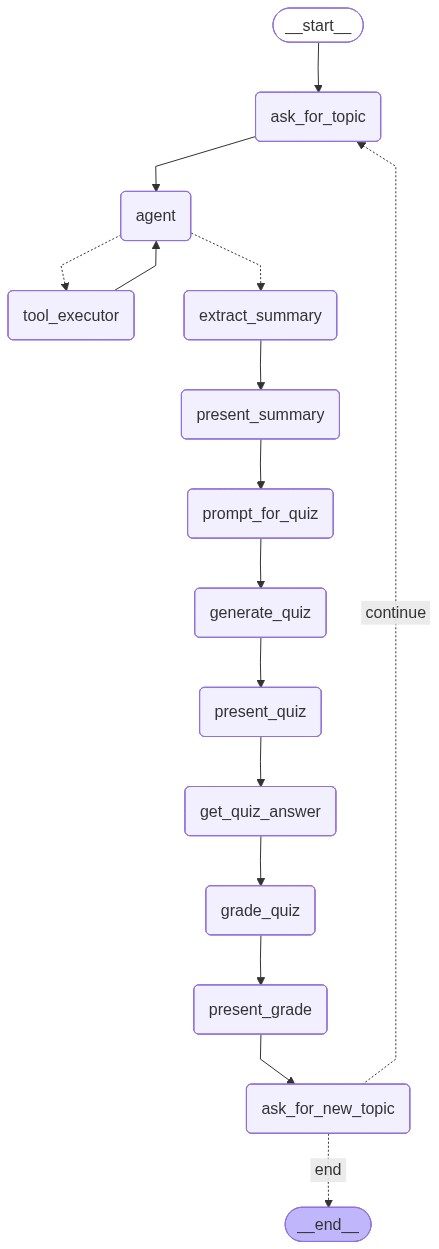

In [37]:
# Build the HealthBot workflow graph
flow = StateGraph(HealthBotState)

# Register nodes
flow.add_node("ask_for_topic", collect_patient_topic)
flow.add_node("agent", run_agent_node)
flow.add_node("tool_executor", execute_search_tool)
flow.add_node("extract_summary", generate_summary)
flow.add_node("present_summary", show_summary)
flow.add_node("prompt_for_quiz", wait_for_quiz_ready)
flow.add_node("generate_quiz", create_quiz_question)
flow.add_node("present_quiz", show_quiz_question)
flow.add_node("get_quiz_answer", collect_quiz_answer)
flow.add_node("grade_quiz", evaluate_quiz_response)
flow.add_node("present_grade", show_quiz_grade)
flow.add_node("ask_for_new_topic", prompt_new_topic)

# Define edges
flow.add_edge(START, "ask_for_topic")
flow.add_edge("ask_for_topic", "agent")
flow.add_conditional_edges(
    "agent",
    decide_tool_usage,
    {
        "tool_executor": "tool_executor",
        "extract_summary": "extract_summary",
    },
)
flow.add_edge("tool_executor", "agent")
flow.add_edge("extract_summary", "present_summary")
flow.add_edge("present_summary", "prompt_for_quiz")
flow.add_edge("prompt_for_quiz", "generate_quiz")
flow.add_edge("generate_quiz", "present_quiz")
flow.add_edge("present_quiz", "get_quiz_answer")
flow.add_edge("get_quiz_answer", "grade_quiz")
flow.add_edge("grade_quiz", "present_grade")
flow.add_edge("present_grade", "ask_for_new_topic")
flow.add_conditional_edges(
    "ask_for_new_topic",
    decide_flow,
    {
        "continue": "ask_for_topic",
        "end": END,
    },
)

# Compile with memory checkpointing
memory_store = MemorySaver()
healthbot_app = flow.compile(checkpointer=memory_store)

# Visualize the graph
display(Image(healthbot_app.get_graph().draw_mermaid_png()))

In [40]:
# Configuration for running the workflow
config = RunnableConfig(
    recursion_limit=2000,
    configurable={"thread_id": "1"}
)

# Initial state for the HealthBot conversation
initial_state = {
    "topic": "",
    "summary": "",
    "quiz": "",
    "quiz_ground_truth": "",
    "answer": "",
    "grade": "",
    "messages": []
}

# Run the workflow once
result = healthbot_app.invoke(initial_state, config)

# Display the final state after one run
print("Final state:", result)

Processing your request...
Looking up information on I'd like to know about diabetes...
---- Tavily Output ---- [{'url': 'https://www.who.int/news-room/fact-sheets/detail/diabetes', 'content': "## Overview\n\nDiabetes is a chronic disease that occurs either when the pancreas does not produce enough insulin or when the body cannot effectively use the insulin it produces. Insulin is a hormone that regulates blood glucose. Hyperglycaemia, also called raised blood glucose or raised blood sugar, is a common effect of uncontrolled diabetes and over time leads to serious damage to many of the body's systems, especially the nerves and blood vessels.\n\nIn 2022, 14% of adults aged 18 years and older were living with diabetes, an increase from 7% in 1990. More than half (59%) of adults aged 30 years and over living with diabetes were not taking medication for their diabetes in 2022. Diabetes treatment coverage was lowest in low- and middle-income countries. [...] The number of people living with